# Neural Networks Week 2 - Building an FNN

This week we will use our Python knowledge to build a Feed-forward Neural Network (FNN) from scratch. We will do this only using packages that we have already worked with, and we will do everything in quite a 'manual' way. This is so that you can get a good understanding of all of the parts that make up a Neural Network in detail. However, building a network in this way is quite laborious, and would certainly not be practical as we get into development of more complex deep learning method. Luckily, there are specialised machine learning packages which allow you to create and train a Neural Network in just a few lines of code, and we will go through an example of those next session. It is important to get a baseline understanding of what is actually happening underneath the surface, but as you go through this session remember that in general when we build these models it is a much simpler process.

First let's import our packages.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1 - Data Setup and Preparation
The dataset we will be working with has two input features: 
- Spd: Wind Speed mean (m/s)
- Dir: Wind Direction (degrees)
- Power: Produced Power (Watts)
  
We will build a very simple Neural Network aiming to predict Power from Dir and Spd. First we will import the data using pandas. This data set is quite large, for quick model training let's start by just looking at the first 10,000 rows. We can later see how changing the data size will affect the time taken to train our model.

In [2]:
data = pd.read_csv('Power_data.csv')[:10000]
data.head()

,Spd,Dir,Power
0,8.057867,140.604963,163091.471006
1,8.261681,194.859499,178473.313441
2,7.880412,267.160458,155353.906329
3,7.709666,244.524946,145472.892782
4,7.610075,139.184019,137384.522086


We will then extract the input feature array, $X$, made up of Spd and Dir, and the output feature array, $Y$, representing Power. We do this by converting the pandas columns to numpy arrays using the `.to_numpy()` method.

#### Recall Exercise 1
What is the difference between a *method* and a generic *function*?

Methods are a subset of functions which are associated with, or built into an object. Whilst functions may take either no variables, or only user-inputted variables, a method must necessarily take in 'self'. A method is called after the object i.e. object.method(), whilst a generic function is just called as function(). We see that for example the `.to_numpy()` method below does not take any arguments, but it automatically takes in the self information of the numpy columns in order to convert them.

In [3]:
X = data[['Spd', 'Dir']].to_numpy()
Y = data.Power.to_numpy()

### Data Reshaping
In general, machine learning packages and algorithms have certain expectations of what input data is supposed to look like. Usually the expectation is that both $X$ and $Y$, regardless of number of features, are inputted into models as 2D arrays with columns representing each feature and rows representing each sample. Some models will accept $Y$ to be input as a 1D array, if there is only a single output feature, but this is not always the case.

| Variable         | Shape                     | n_features = 1 | n_features = 2 |
| ---------------- | ------------------------- | ------------- |  -------------- |
| **X (features)** | `(n_samples, n_features)` | 2D matrix (n_samples,1)    | 2D matrix |
| **y (target)**   | `(n_samples, n_features)` | 2D matrix (n_samples,1 )  or 1D vector (n_samples, )  | 2D matrix  |

Let's look at the current shapes of our input variables.

In [4]:
print(X.shape)
print(Y.shape)
print(Y)

(10000, 2)
(10000,)
[163091.47100571 178473.31344111 155353.9063291  ... 157417.40763165
 167307.23794608 165826.34028525]


$X$ is already 2D, since we have multiple features, however $Y$ has been output as a 1D vector. Automatically this is treated as a row vector, when we want it to be interpreted as a 2D column. Let's reshape it using the NumPy inbuilt method `.reshape()`.

In [5]:
Y = Y.reshape(-1,1)
Y.shape
print(Y)

[[163091.47100571]
 [178473.31344111]
 [155353.9063291 ]
 ...
 [157417.40763165]
 [167307.23794608]
 [165826.34028525]]


### Normalisation
We then need to *normalise* our input and output. 
It is essential to normalise our input since Neural Networks are highly sensitive to the *scale* and *distribution* of input features. Normalisation allows us to alter the statistical properties of the features to ensure they are in line with each other. For example, if we have two different features measuring something similar but with different units such as two wind speed variables one in m/s and one in km/s, normalising would return them to the same scale. The remainder of this section is optional. You may minimise this section by selecting the small arrow to the top left of this cell.

Normalising inputs has several advantages:
1. Faster Convergence

When features are on very different scales (e.g. wind speed standard deviation 0-1 and power: 0-2,500,000), then when we perform gradient descent the gradients can become very unbalanced as the large-scale features dominate weight updates. Normalising rebalances this so that gradient descent can move efficiently towards the minimum, working equally in each feature direction.

3. Gradient Stability
   
Neural Networks use a method called backpropagation. If inputs are poorly scaled then activations may become very large or very small. Gradients can explode or vanish (especially with sigmoid/tanh). Normalised inputs keep activations in reasonable ranges, improving numerical stability.

5. Prevents Saturation of Activation Functions
   
For some activation functions (such as sigmoid or tanh), large positive or negative values can lead to 'saturation zones'. This is usually where we have a tangent, or very low gradient, area of the function (think about the shape of the tan graph close to the axes). In these zones learning is very slow as gradients are close to 0. Normalising inputs helps to keep activations in the sensitive (linear) regions of these functions.

7. Fair Feature Contribution

Without normalisation, features with larger numeric ranges disproportionately influence learning and the model may ignore important features because they have a small-scale. Normalisation ensures each feature contributes more equally.

If we don't normalise we may suffer issues such as:

- Slower training
- More unstable learning
- Harder hyperparameter tuning
- Possible failure to converge

There are several ways we can carry out normalisation. We can normalise all of our inputs (input normalisation) at the same time or use:

- Batch Normalisation (normalizes layer activations during training)
- Layer Normalisation
- Instance Normalisation

For this tutorial we will only use input normalisation, where we normalise everything at the start of the process.

#### Common Normalization Techniques
- Min-Max Scaling (Rescaling)

This method ensures values lie within a fixed range, usually [0, 1]. The minimum value is subtracted from each value, and the result is divided by the range of results:
$$x' = \frac{x-x_{min}}{range} = \frac{x-x_{min}}{x_{max}-x_{min}}.$$​
For the minimum value in the set the numerator will be $x_{min}-x_{min}$=0 and so the result is 0, for the largest value in the dataset the numerator will be $x_{max}-x_{min}$, equivalent to the denominator and the result is 1. Thus for any dataset values the new range falls between 0 and 1.

In [6]:
X_norm_minmax = [(x-np.min(X))/(np.max(X)-np.min(X)) for x in X]
print(f'Original Range: [{np.min(X), np.max(X)}]')
print(f'New Range: [{np.min(X_norm_minmax), np.max(X_norm_minmax)}]')

Original Range: [(0.0057347773997573, 359.97917561440727)]
New Range: [(0.0, 1.0)]


- Standardization (Z-score Normalization)

This method centres the data at 0 and rescales the standard deviation to be 1. It works by subtracting the mean, and dividing by the standard deviation:

$$x'=\frac{x-\mu}{\sigma}.$$
	​
This method is the most common choice for Neural Networks. It works especially well for ReLU, Tanh and gradient-based optimisers.

#### Exercise 1.1
Normalise $X$ using this method, and compare the old and new mean and standard deviation values.

In [7]:
mu = np.mean(X)
sigma = np.std(X)
X_norm_zscore = [(x-mu)/sigma for x in X]

print(f'Old Mean: {mu}')
print(f'Old Standard Deviation: {sigma}')
print(f'New Mean: {np.round(np.mean(X_norm_zscore),3)}')
print(f'New Standard Deviation: {np.std(X_norm_zscore)}')

Old Mean: 93.71277649624788
Old Standard Deviation: 112.67519588794991
New Mean: 0.0
New Standard Deviation: 1.0


The new mean is 0 and the new standard deviation are 1. The variance is now significantly reduced and the distribution is centred at 0 rather than 93.7, making this data much easier to work with.

- Mean Normalization

Centers data but may not scale variance.
$$ x' = \frac{x-\mu}{x_{max}-x_{min}}$$


- Robust Scaling

Scales data using median and interquartile range (IQR):

$$x' = \frac{x-median}{IQR}.$$
	​
This method performs well when the data contains outliers or the distribution is skewed. For example, if we have most data within range 1-50 with an outlier of 200 and scale using min-max scaling, our new range would be 0-1 but the majority of the data would be 0-0.25.

#### Exercise 1.2
Below we have created a data set of 100 points between 0-1, and two outliers that are much larger. Normalise this data using both min-max and robust scaling. What are the key differences in the results?

In [8]:
nice_data = np.random.rand(100)
outlier_data = np.append(nice_data, [10,10])

outlier_data_minmax = [(x-np.min(outlier_data))/(np.max(outlier_data)-np.min(outlier_data)) for x in outlier_data]
print(f'Range: {np.round(np.min(outlier_data_minmax),2), np.round(np.max(outlier_data_minmax),2)}')
print(f'Mean: {np.mean(outlier_data_minmax)}')

lower_quartile = np.percentile(outlier_data, 25)
upper_quartile = np.percentile(outlier_data, 75)
iqr = upper_quartile-lower_quartile

outlier_data_robust = [(x-np.median(outlier_data))/iqr for x in outlier_data]
print(f'Range: {np.round(np.min(outlier_data_robust),2), np.round(np.max(outlier_data_robust),2)}')
print(f'Mean: {np.mean(outlier_data_robust)}')

Range: (0.0, 1.0)
Mean: 0.07327010917680471
Range: (-1.39, 21.47)
Mean: 0.28737068937797744


- Log Transformation
  
Useful for highly skewed features by reducing long tails using the logarithm function. This method takes the log of $x$ combined with a tunable scalar paramater, $x$:
$$x' = log(x+c).$$

In [9]:
X_norm_log = [np.log(x+5) for x in X]

- Unit Vector Normalization (L2 normalisation)

Scales each sample vector to have unit norm by dividing by the absolute value of each entry.

$$x' = \frac{x}{||x||}​.$$

In [10]:
X_norm_l2 = [x/np.abs(x) for x in X]

This session we will carry out Z-score normalisation. 

In [11]:
# Normalize X 
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_norm = (X - X_mean) / X_std

Normlising output is usually less important than normalising input but it is good practice and comes with advantages for certain situations.

In [12]:
# Normalize Y (optional but often helpful)
Y_mean = Y.mean(axis=0)
Y_std = Y.std(axis=0)
Y_norm = (Y - Y_mean) / Y_std

### Splitting data into training and test sets

Our data has now been reshaped to be the correct dimensions, and has been standardised to be the correct distribution so it could be directly fed into a model as is. However, there is one more step of data preparation that is highly important - splitting our data for training and testing. When we feed a model data it tries to learn a pattern from the data it has available. As we increase the complexity of our model, it will pick up on more patterns and learn more complex and subtle patterns in the data. This comes with a certain level of risk. As we learnt in the statistics part of the course, most data sets we have are not exact actualisations of the 'true' distribution (or function) of the data, $y=f(x)$, but come additionally with some noise as 
$$Y = f(x) + N(x).$$
This noise is often a random function and cannot be 'learnt' or picked up well by a trained model. This can lead to the problem of *overfitting*, where a complex model attempts to explain noise or variance of data. The image below shows a (roughly sketched) example. Imagine we have a training data set represented by the black circles. A likely true, or well fitting model, would be the blue curve. This curve explains the shape of the data, understanding that there is some noise and variance within the data. The red line represents an overfitted model. By training to explain data exactly, we have fitted an overly complex model. If we looked only at the data we used to train the model, the red line would score higher on testing metrics. It is 100% accurate at predicting the training data. However, when we introduce new, unseen data (green circles), the model no longer performs well. We would say that it does not *generalise well*. This means that whilst it performs well on the specific training set, it does not perform well when we generalise it to the larger population.
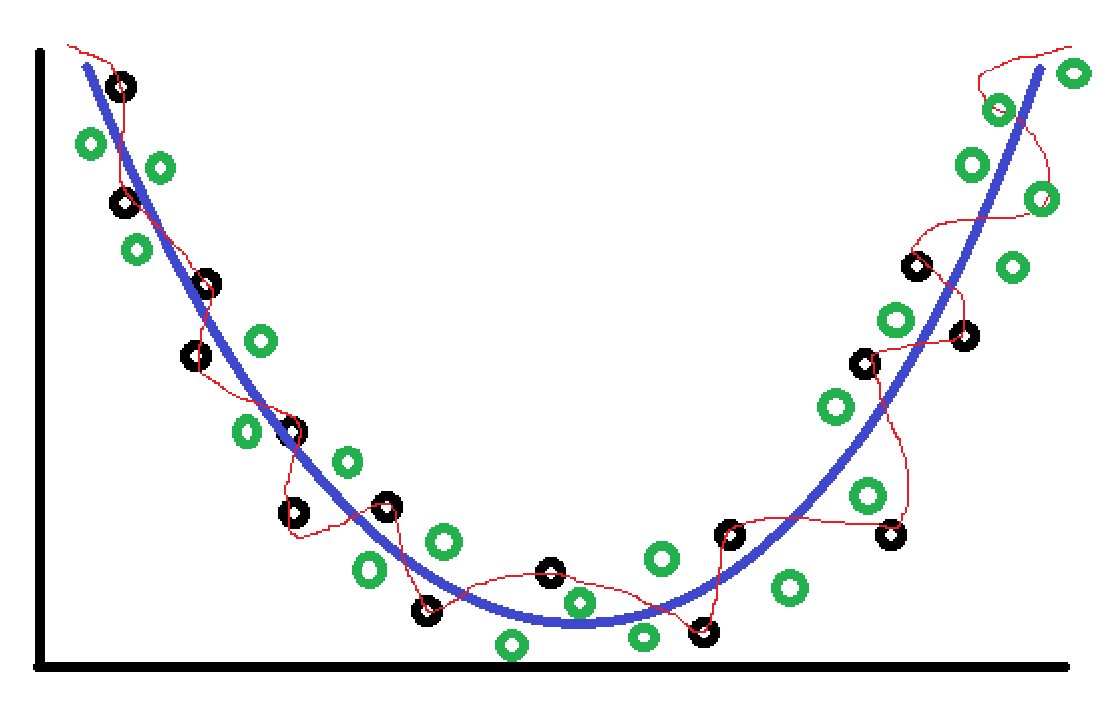

We can reduce the risk of this problem by retaining some of our data for testing. This means that we train the model on a large percentage of our data, and keep some aside which the model has not seen. When we test the the model on these unseen points we can then see if the model generalises well to new data or if it has overfitted. Generally, if a model performs significantly better on the training data than the test data then it is likely that the model has overfitted.

There are lots of different ways to split our data, and some methods involve splitting the data into three different sets rather than just 2. We will discuss this in more depth in the model optimisation section of the course. For now, a good rule of thumb is to retain around 20% of the data for testing. We will use an inbuilt numpy method `random.permutation(n)` to shuffle our indices at random, and then split these into 2 sets of 80% and 20% of the data respectively. Importantly, the indices from the train and test sets for X must be the same as for Y so the correct labels stay with their respective input data.

In [13]:
idx = np.random.permutation(len(X))
train_idx, test_idx = idx[:int(0.8*len(X))], idx[int(0.8*len(X)):]

X_train, X_test, Y_train, Y_test = X_norm[train_idx], X_norm[test_idx], Y_norm[train_idx], Y_norm[test_idx]

## 2 - Model setup
Now our data is ready we can start building our Neural Network!
We are going to build a very simple single-layered Neural Network with 8 neurons in the hidden layer.
This network will look something like this:

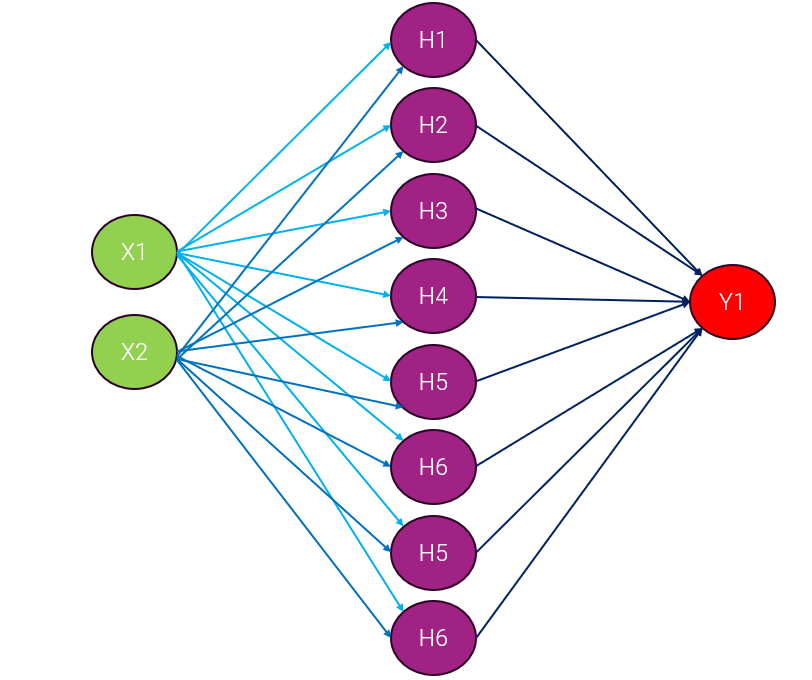


Recall from last week how information is combined from input layer to hidden layer. Each link between input point and hidden neuron has an associated *weight*. We initialise these weights as an array with size (input layer size, hidden layer size). This means that each row represents one of the input points and each column represents a hidden layer neuron. Many machine learning packages will have optimal ways to initialise these weights, but for this example we randomly generate weights between 0 and 0.1.

Each hidden neuron also has a *bias* term, that is added to the sum of weighted inputs. We initialise this as an array with a single column representing a bias for each hidden neuron. For this example we will initially set all biases to be 0.

The same process is carried out to initialise these variables for the edges between hidden layer and output layer.

In [14]:
# Initialize parameters
input_size = 2
hidden_size = 8
output_size = 1

W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros((1, output_size))

## Activation Function
You may remember from the previous session that there is one more variable in how information is processed between layers, the *activation function*. This is how the input data is transformed using a simple function. There are many different types of activation function but the most commonly used ones are summarised below. This section is an optional read, and you may skip to Model Training if preferred. You can hide these cells by clicking the small arrow to the top left of this cell.

**Linear Activation Function**

The linear activation function is a simple straight line relationship characterised by
$$y = mx+c.$$
If an FNN uses only linear activation functions the final output results are always a linear combination of the input. The range of this function is $(-\infty, \infty)$, which limits it's usefulness in controlling the output range. The linear activation function is generally used to convert between final hidden layer and output layer. Linear activation functions are useful for some specific needs, but an FNN cannot soley rely on these functions as they would greatly limit the ability to learn complex pattern (it would ultimately be a linear regression model).

**Sigmoid Function**
  
The Sigmoid Activation Function is characterized by an 'S' shape. It is mathematically defined as $$A = \frac{1}{1+e^{-x}}.$$
Unlike the linear activation function, this method allows for a strictly controlled range between 0 and 1. 

**Tanh Activation Function**

Tanh function(hyperbolic tangent function) is a shifted version of the sigmoid, allowing it to stretch across the y-axis. It is defined as:$$A = tanh(x) = \frac{2}{1+e^{-2x}}-1 = 2 \text{ sigmoid}(2x)-1.$$

The range of this function is limited from -1 to 1. Since this method is non-linear it enables modeling of complex data patterns. It is commonly used within hidden layers due to its zero-centred output, making learning easier for later layers.

**ReLU (Rectified Linear Unit) Function**

The ReLU activation is defined by$$A(x) = max(0,x),$$
A(x)=max(0,x), this means that if the input x is positive, ReLU returns x, if the input is negative, it returns 0.$[0, \infty),$
meaning the function only outputs non-negative values.

**Leaky ReLU**
$$A = \begin{cases} 
x & \text{ if } x>0\\
x\alpha x & \text{ if } x \leq 0
\end{cases}$$

**Softmax Function**

Softmax function is designed to handle multi-class classification problems. It transforms raw output scores from a neural network into probabilities. It works by squashing the output values of each class into the range of 0 to 1 while ensuring that the sum of all probabilities equals 1.

Softmax is a non-linear activation function.
The Softmax function ensures that each class is assigned a probability, helping to identify which class the input belong

Impact of Activation Functions on Model Performance
The choice of activation function has a direct impact on the performance of a neural network in several ways:

Convergence Speed: Functions like ReLU allow faster training by avoiding the vanishing gradient problem while Sigmoid and Tanh can slow down convergence in deep networks.
Gradient Flow: Activation functions like ReLU ensure better gradient flow, helping deeper layers learn effectively. In contrast Sigmoid can lead to small gradients, hindering learning in deep layers.
Model Complexity: Activation functions like Softmax allow the model to handle complex multi-class problems, whereas simpler functions like ReLU or Leaky ReLU are used for basic layers. problems during optimization.s to.d in some cases for better gradient flow.and easy for computation., facilitating easier learning for subsequent layers.the training process. capabilities.

For this session we are using the ReLu function. This takes the maximum between 0 and the input. This means it sets any negative value to 0. Below we define the relu function and it's derivative (for back propagation).

In [15]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

## Model Training
There are two more variables we need to determine how we conduct our training.

**Learning rate**:
The learning rate determines how much we adjust the weight and bias variables at each step of optimisation. A higher learning rate adjusts more significantly with each new round of training. A low learning rate moves in smaller increments and converges slower and less efficiently, but a learning rate that is too high can overshoot and overcorrect to new information, varying wildly and failing to converge. We will cover selection options for learning rate in the hyperparameter optimisation part of the course, a sensible starting point is 0.01 which tends to display low variance.

**Epochs**:
An epoch is a training cycle. The number of epochs determines how many times we alter our parameters. A higher number of epochs is needed if we have a lower learning rate, or a more complex model.. 

In [16]:
learning_rate = 0.01
epochs = 1000

The model hyperparameters are set. All we need to do now is optimise the weights and biases and we will have a complete model. You may recall from last session that we do this through a process called *back propagation*. At each training step (or epoch) we carry out the following steps:
1. We use the first set of weights and biases, $W_1$ and $b_1$, to calculate a $Z$ array: this is the value that each hidden node receives.
2. We then calculate the activation function for each of these values $[z_1, z_2, \cdots, z_8]$ to get $A_1$, the values that are outputted from the hidden layer
3. We use the second set of weights and biases, $W_2$ and $b_2$, to calculate a second $Z$ array.
4. We calculate the activation function for each of these values. This gives us our predicted output values $Y_{pred}$.
5. A loss, $\mathcal{L}$ is calculates using Mean Squared Error as $$\mathcal{L} = \frac{1}{N} \sum^N_{i=1} (Y_{pred, i}-Y_{train, i})^2,$$
   where $N$ is the number of training data points
6. The derivatives are calculated for each weight and bias array, and parameters are updated as
   $$W_i = W_i-\eta\cdot \frac{d\mathcal{L}}{dW_i}$$
    $$b_i = b_i-\eta\cdot \frac{d\mathcal{L}}{db_i},$$
   where $\eta$ is the learning rate.
   Recall that what is happening here is we are changing the parameter in line with the gradient of the loss function with respect to that parameter,      scaled by the learning rate.

We repeat this process until we have completed all epochs. At each stage we should see a reduction in loss due to our weight adjustments. Let's carry this out using python code, and print our loss every 100 epochs.

In [17]:
n = X_train.shape[0]

for epoch in range(epochs):

    # ----- Forward pass -----
    Z1 = X_train @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    Y_pred = Z2  # Linear output

    # ----- Loss (MSE) -----
    loss = np.mean((Y_pred - Y_train) ** 2)

    # ----- Backpropagation -----
    dZ2 = 2 * (Y_pred - Y_train) / n
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X_train.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # ----- Update weights -----
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 0.9822
Epoch 100, Loss: 0.6688
Epoch 200, Loss: 0.1071
Epoch 300, Loss: 0.0350
Epoch 400, Loss: 0.0331
Epoch 500, Loss: 0.0322
Epoch 600, Loss: 0.0315
Epoch 700, Loss: 0.0308
Epoch 800, Loss: 0.0301
Epoch 900, Loss: 0.0294


## 3 - Model Testing
We've optimised our parameters on the training data to create our final model - let's see how well it performs. First we need to calculate our predictions for the training data sets. Remember since we normalised our paramaters in the beginning, we will need to denormalise to get true outputs.

In [18]:
# Predict
Z1 = X_train @ W1 + b1
A1 = relu(Z1)
Z2 = A1 @ W2 + b2
Y_pred_train_norm = Z2

# Denormalize
Y_pred_train = Y_pred_train_norm * Y_std + Y_mean

Let's do the same for our test set.

In [19]:
# Predict
Z1 = X_test @ W1 + b1
A1 = relu(Z1)
Z2 = A1 @ W2 + b2
Y_pred_test_norm = Z2

# Denormalize
Y_pred_test = Y_pred_test_norm * Y_std + Y_mean

Finally let's see how the model performed when we compare these predictions with the true data labels.

In [20]:
# Denormalise true labels
Y_train_denormed = Y_train * Y_std + Y_mean
Y_test_denormed = Y_test * Y_std + Y_mean

# Calculate RMSE
rmse_train = np.sqrt(np.mean([(Y_pred_train[i]-Y_train_denormed[i])**2 for i in range(len(Y_pred_train))]))
rmse_test = np.sqrt(np.mean([(Y_pred_test[i]-Y_test_denormed[i])**2 for i in range(len(Y_pred_test))]))

# Calculate MPE (mean percentage error)
mpe_train = np.mean([(Y_pred_train[i]-Y_train_denormed[i])/Y_train_denormed[i]*100 for i in range(len(Y_pred_train))])
mpe_test = np.mean([(Y_pred_test[i]-Y_test_denormed[i])/Y_test_denormed[i]*100 for i in range(len(Y_pred_test))])

print('Training Set Performance')
print(f'RMSE: {np.round(rmse_train, 2)}')
print(f'MPE: {np.round(mpe_train, 3)}%')

print('Test Set Performance')
print(f'RMSE: {np.round(rmse_test, 2)}')
print(f'MPE: {np.round(mpe_test, 3)}%')

Training Set Performance
RMSE: 2121.6
MPE: 0.017%
Test Set Performance
RMSE: 2072.85
MPE: -0.044%


We see that the RMSE (root mean squared error) is slightly higher when we generalise to the test set but they are relatively similar values, and the mean percentage errors are very close. This suggests that the model generalises well to unseen data.

## 4 - Model Tuning
Let's combine all of our code together to revise the full process - it is worth looking through all of the code cell below and making sure you understand each step. At the top of the code I have specified some key model hyperparameters that define the model. Please take the time to carry out Exercise 4 which will look at how changing these affects the model. In order to test how model efficiency is affected, we will use a python package called time to get the time before and after we carry out the training process and calculate the difference between them.

In [21]:
import time

In [22]:
data_size = 10000
learning_rate = 0.01
epochs = 1000
train_proportion = 0.8
hidden_size = 8

# Prepare Data
# ---- extract data ----
data = pd.read_csv('Power_data.csv')[:data_size]
X = data[['Spd', 'Dir']].to_numpy()
Y = data.Power.to_numpy()

# ---- reshape data ----
Y = Y.reshape(-1,1)

# ---- normalize data ----
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_norm = (X - X_mean) / X_std
Y_mean = Y.mean(axis=0)
Y_std = Y.std(axis=0)
Y_norm = (Y - Y_mean) / Y_std

# ---- split data into train and test ----
idx = np.random.permutation(len(X))
train_idx, test_idx = idx[:int(train_proportion*len(X))], idx[int(train_proportion*len(X)):]

X_train, X_test, Y_train, Y_test = X_norm[train_idx], X_norm[test_idx], Y_norm[train_idx], Y_norm[test_idx]

# Set-up Model
# ---- define our activation function and derivative ----
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

# ---- initialise weights and biases ----
W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros((1, output_size))


# Train model
n = X_train.shape[0]

before = time.time()

for epoch in range(epochs):

    # ----- Forward pass -----
    Z1 = X_train @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    Y_pred = Z2  # Linear output

    # ----- Loss (MSE) -----
    loss = np.mean((Y_pred - Y_train) ** 2)

    # ----- Backpropagation -----
    dZ2 = 2 * (Y_pred - Y_train) / n
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X_train.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # ----- Update weights -----
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

after = time.time()

print(f'Time taken (seconds): {np.round(after-before,2)}')

# Test model
# ---- predict for training set -----
Z1 = X_train @ W1 + b1
A1 = relu(Z1)
Z2 = A1 @ W2 + b2
Y_pred_train_norm = Z2

# ---- denormalize training output ----
Y_pred_train = Y_pred_train_norm * Y_std + Y_mean

# ---- predict for test set -----
Z1 = X_test @ W1 + b1
A1 = relu(Z1)
Z2 = A1 @ W2 + b2
Y_pred_test_norm = Z2

# ---- denormalize test output ----
Y_pred_test = Y_pred_test_norm * Y_std + Y_mean

# ---- denormalise true labels ----
Y_train_denormed = Y_train * Y_std + Y_mean
Y_test_denormed = Y_test * Y_std + Y_mean

# ---- calculate RMSE ----
rmse_train = np.sqrt(np.mean([(Y_pred_train[i]-Y_train_denormed[i])**2 for i in range(len(Y_pred_train))]))
rmse_test = np.sqrt(np.mean([(Y_pred_test[i]-Y_test_denormed[i])**2 for i in range(len(Y_pred_test))]))

# ---- calculate MPE (mean percentage error) ----
mpe_train = np.mean([(Y_pred_train[i]-Y_train_denormed[i])/Y_train_denormed[i]*100 for i in range(len(Y_pred_train))])
mpe_test = np.mean([(Y_pred_test[i]-Y_test_denormed[i])/Y_test_denormed[i]*100 for i in range(len(Y_pred_test))])

# ---- print results ----
print('Training Set Performance')
print(f'RMSE: {np.round(rmse_train, 2)}')
print(f'MPE: {np.round(mpe_train, 3)}%')

print('Test Set Performance')
print(f'RMSE: {np.round(rmse_test, 2)}')
print(f'MPE: {np.round(mpe_test, 3)}%')

Time taken (seconds): 0.9
Training Set Performance
RMSE: 2120.29
MPE: 0.026%
Test Set Performance
RMSE: 2052.18
MPE: 0.023%


#### Exercise 4

Edit the following parameters one at a time:
- data_size (number of data points used) [suggested range <=100,000]
- learning_rate (learning rate) [suggested range 0.0001 to 1]
- epochs (number of training cycles) [suggested range <=10,000]
- train_proportion (percentage of data used for training) [>0, <1]
- hidden_size (number of neurons in hidden layer) [suggested range <= 128]

You don't need to stick to the suggested ranges but these are guardrails to avoid very slow running or errors.

Test at least 3 examples for each of these parameters and see how it affects:
- The training set performance
- The test set performance
- The time taken to carry out the training process.

#### Extension Exercise
Alter the activation function to use some of the other common options. How does this affect model performance?